In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import glob
from pathlib import Path
import os
import zipfile
import os
from shapely.geometry import Point

In [2]:
# Nepal Map Shape file dataset
zip_path = "nepal_shape/npl_admin_boundaries.shp.zip"
extract_path = "nepal_shape/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [3]:
nepal_map = gpd.read_file("nepal_shape/npl_admin2.shp")
# nepal_map['adm2_name', 'adm1_name', 'adm1_pcode', 'area_sqkm', 'cod_versio', 'center_lat', 'center_lon', 'geometry']
nepal_map.head()

,adm2_name,adm2_name1,adm2_name2,adm2_name3,adm2_pcode,adm1_name,adm1_name1,adm1_name2,adm1_name3,adm1_pcode,...,valid_to,area_sqkm,cod_versio,lang,lang1,lang2,lang3,center_lat,center_lon,geometry
0,Taplejung,None,None,None,NP0101,Koshi,None,None,None,NP01,...,NaT,3631.813309,V_02,en,None,None,None,27.610463,87.821542,"POLYGON ((87.83403 27.95158, 87.83465 27.95139..."
1,Panchthar,None,None,None,NP0102,Koshi,None,None,None,NP01,...,NaT,1247.722512,V_02,en,None,None,None,27.148871,87.855072,"POLYGON ((88.07442 27.43312, 88.07464 27.43312..."
2,Ilam,None,None,None,NP0103,Koshi,None,None,None,NP01,...,NaT,1685.282883,V_02,en,None,None,None,26.885396,87.920240,"POLYGON ((87.95472 27.10455, 87.95545 27.10444..."
3,Jhapa,None,None,None,NP0104,Koshi,None,None,None,NP01,...,NaT,1603.810951,V_02,en,None,None,None,26.583568,87.885501,"POLYGON ((88.15222 26.80584, 88.1528 26.80534,..."
4,Morang,None,None,None,NP0105,Koshi,None,None,None,NP01,...,NaT,1822.340361,V_02,en,None,None,None,26.610614,87.473116,"POLYGON ((87.50698 26.8704, 87.50738 26.86958,..."


In [4]:
# Overall Fire incidents dataset: 2020-2024
shp_files = list(Path("data/Fire Incidents/").glob("*/*.shp"))

shp_files = [f for f in shp_files if not f.name.startswith("._")]

fire_data_list = []

for file in shp_files:
    try:
        gdf = gpd.read_file(file)
        
        year = file.parent.name
        gdf['year'] = int(year)
        
        fire_data_list.append(gdf)
    
    except Exception as e:
        print(f"Skipping file: {file} → {e}")

fire_data = gpd.GeoDataFrame(pd.concat(fire_data_list, ignore_index=True))

fire_data.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,year
0,26.90225,85.80494,328.11,0.40,0.37,2020-01-02,0729,N20,VIIRS,n,2,290.10,2.20,D,0,POINT (85.80494 26.90225),2020
1,27.47337,84.33176,328.18,0.38,0.36,2020-01-02,0729,N20,VIIRS,n,2,291.14,2.03,D,0,POINT (84.33176 27.47337),2020
2,27.47309,82.85561,327.18,0.40,0.37,2020-01-02,0729,N20,VIIRS,n,2,293.35,2.15,D,0,POINT (82.85561 27.47309),2020
3,28.77123,80.20963,337.18,0.49,0.49,2020-01-05,0814,N20,VIIRS,n,2,290.54,6.05,D,0,POINT (80.20963 28.77123),2020
4,27.62135,83.08981,295.71,0.42,0.38,2020-01-06,2020,N20,VIIRS,n,2,277.86,0.42,N,0,POINT (83.08981 27.62135),2020


In [7]:
import rasterio

raster_paths = {
    2020: "data/Land Cover/2020/lc2020.tif",
    2021: "data/Land Cover/2021/lc2021.tif",
    2022: "data/Land Cover/2022/lc2022.tif" 
}

forest_raster_2022 = rasterio.open(raster_paths[2022])

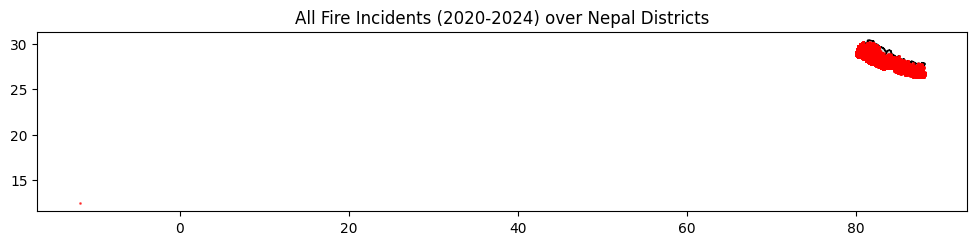

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
nepal_map.plot(ax=ax, color='lightgray', edgecolor='black')
fire_data.plot(ax=ax, markersize=1, color='red', alpha=0.6)
ax.set_title("All Fire Incidents (2020-2024) over Nepal Districts")
plt.show()

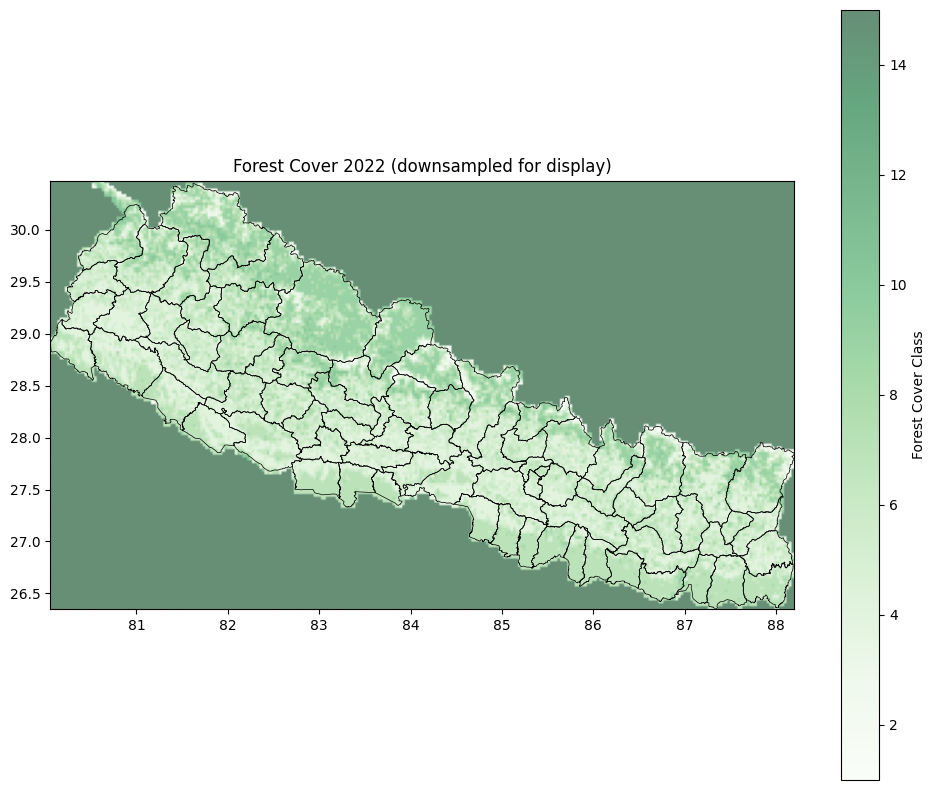

In [11]:
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

with rasterio.open("data/Land Cover/2022/lc2022.tif") as src:
    # Downsample factor (e.g., 0.01 = 1% of original size)
    factor = 0.01
    new_width = int(src.width * factor)
    new_height = int(src.height * factor)
    
    # Read the first band at reduced resolution
    forest_small = src.read(1, out_shape=(new_height, new_width), resampling=Resampling.bilinear)
    
    # Update transform for the downsampled array
    transform = src.transform * src.transform.scale(
        src.width / new_width,
        src.height / new_height
    )

# Plot downsampled raster
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(forest_small, extent=(transform[2], transform[2] + transform[0]*new_width,
                                      transform[5] + transform[4]*new_height, transform[5]), 
               cmap='Greens', alpha=0.6)
nepal_map.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
plt.colorbar(im, ax=ax, label='Forest Cover Class')
ax.set_title("Forest Cover 2022 (downsampled for display)")
plt.show()

In [14]:
import numpy as np

# Reproject fire points to the raster's CRS (often UTM)
fires_proj = fire_data.to_crs(forest_raster_2022.crs)

# Extract forest value at each fire location
coords = [(geom.x, geom.y) for geom in fires_proj.geometry]
forest_vals = [val[0] for val in forest_raster_2022.sample(coords)]
fire_data['forest_val'] = forest_vals

# Define forest class (example: 1 = forest). Change based on your legend.
FOREST_CLASS = 1
fires_forest = fire_data[fire_data['forest_val'] == FOREST_CLASS].copy()

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx

# Ensure nepal_map and fires_forest are defined
# nepal_map = districts (GeoDataFrame)
# fires_forest = filtered forest fires (GeoDataFrame)

# Reproject to Web Mercator (EPSG:3857) for proper basemap and scale
nepal_map_mercator = nepal_map.to_crs("EPSG:3857")
fires_forest_mercator = fires_forest.to_crs("EPSG:3857")

# Create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Plot district boundaries (light gray fill with black boundary)
nepal_map_mercator.plot(ax=ax, facecolor='whitesmoke', edgecolor='black', linewidth=0.8, alpha=0.6)

# Plot forest fires with color based on FRP intensity
# If FRP column exists, use it; otherwise, fallback to uniform blue
if 'FRP' in fires_forest.columns:
    # Normalize FRP for color mapping (use a logarithmic scale if skewed)
    scatter = ax.scatter(fires_forest_mercator.geometry.x, 
                         fires_forest_mercator.geometry.y,
                         c=fires_forest_mercator['FRP'], 
                         cmap='hot', s=15, alpha=0.8, 
                         edgecolors='none', vmin=0, vmax=fires_forest_mercator['FRP'].quantile(0.95))
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Fire Radiative Power (FRP)', fontsize=10)
else:
    # Fallback: uniform blue points
    fires_forest_mercator.plot(ax=ax, markersize=2, color='blue', alpha=0.7, label='Forest Fires')

# Add a basemap (requires internet connection)
ctx.add_basemap(ax, crs=fires_forest_mercator.crs, source=ctx.providers.CartoDB.Positron)

# Add scale bar (in kilometers)
scalebar = ScaleBar(dx=1, units="m", dimension="si-length", location="lower right", 
                    scale_loc="bottom", label_loc="top", length_fraction=0.2)
ax.add_artist(scalebar)

# Add north arrow (using an annotation arrow)
x, y = 0.85, 0.85  # position in axis coordinates
ax.annotate('N', xy=(x, y), xycoords='axes fraction', fontsize=14, ha='center', va='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.annotate('', xy=(x, y-0.05), xytext=(x, y), xycoords='axes fraction', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Title and subtitles
total_fires = len(fires_forest)
ax.set_title(f"Forest Fires in Nepal (2020–2024)\nTotal fires in forest areas: {total_fires}", 
             fontsize=14, pad=20)

# Remove axes ticks for cleaner look
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
show(forest_raster_2022, ax=ax, cmap='Greens', alpha=0.5)
fires_forest.plot(ax=ax, markersize=2, color='red')
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title("Forest Fires over Forest Cover Map")
plt.show()

In [ ]:
# Load district boundaries (again for attribute join)
districts_attr = nepal_map['adm2_name', 'geometry'].to_crs("EPSG:4326")

# Spatial join to assign district name to each forest fire
fires_forest = gpd.sjoin(fires_forest, districts_attr, how='left', predicate='within')
fires_forest = fires_forest.rename(columns={'adm2_name': 'District'})

# Load district-level CSV features
df_features = pd.read_csv("district_features.csv")  # columns: District, year, slope, pop_density, road_density, rainfall, forest_cover_pct

# Merge by District and year
fires_model = fires_forest.merge(df_features, on=['District', 'year'], how='left')

In [ ]:
# Aggregate predictions by district
district_pred = fires_model.groupby('District')['predicted_intensity'].mean().reset_index()
districts_map = districts.merge(district_pred, left_on='adm2_name', right_on='District', how='left')

# Plot predicted intensity map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
districts_map.plot(column='predicted_intensity', cmap='Reds', legend=True, ax=ax,
                   legend_kwds={'label': 'Mean Predicted Fire Intensity (FRP)'})
ax.set_title("Forest Fire Intensity Prediction by District")
plt.show()